# Food Rescue CV: Data Pipeline Setup
Food-101 loading, preprocessing, and stratified data-fraction splits (10%/50%/100%) for ResNet18 vs ViT-B/16 comparison.

## 1. Mount Google Drive
This keeps data, checkpoints, and logs persistent across Colab session resets.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/food-rescue-cv'
os.makedirs(PROJECT_DIR, exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/data', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/checkpoints', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/results', exist_ok=True)
print('Project dir ready at', PROJECT_DIR)

Mounted at /content/drive
Project dir ready at /content/drive/MyDrive/food-rescue-cv


## 2. Install packages

In [2]:
!pip install -q timm wandb

import torch
import torchvision
print('torch', torch.__version__, '| cuda available:', torch.cuda.is_available())

torch 2.11.0+cu128 | cuda available: True


## 3. Load Food-101
Downloads once to Drive-backed storage. `torchvision.datasets.Food101` handles train/test splits automatically.

In [3]:
from torchvision.datasets import Food101

DATA_ROOT = '/content/food101_data'  # local disk, faster download, not persisted

train_set = Food101(root=DATA_ROOT, split='train', download=True)
test_set = Food101(root=DATA_ROOT, split='test', download=True)

print('Train size:', len(train_set))
print('Test size:', len(test_set))
print('Num classes:', len(train_set.classes))
print('Sample classes:', train_set.classes[:5])

100%|██████████| 5.00G/5.00G [03:40<00:00, 22.7MB/s]


Train size: 75750
Test size: 25250
Num classes: 101
Sample classes: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare']


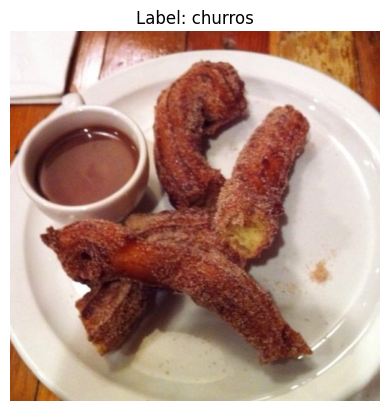

In [4]:
# Spot check: view a sample image and its label
import matplotlib.pyplot as plt

img, label = train_set[0]
plt.imshow(img)
plt.title(f'Label: {train_set.classes[label]}')
plt.axis('off')
plt.show()

## 4. Preprocessing
Shared transforms for ResNet18 and ViT-B/16 (both pretrained on ImageNet). Keeping preprocessing identical across models so performance differences come from architecture, not input handling.

In [5]:
from torchvision import transforms

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Reload datasets with transforms applied
train_set = Food101(root=DATA_ROOT, split='train', transform=train_transform, download=False)
test_set = Food101(root=DATA_ROOT, split='test', transform=eval_transform, download=False)

## 5. Stratified data-fraction splits (10% / 50% / 100%)
Each class proportionally represented at every fraction, reproducible via fixed seed.

In [6]:
import numpy as np
from collections import defaultdict
from torch.utils.data import Subset

SEED = 42

def stratified_subset(dataset, fraction, seed=SEED):
    """Return a Subset containing `fraction` of each class, stratified."""
    if fraction >= 1.0:
        return dataset

    rng = np.random.default_rng(seed)

    # Group indices by class label
    class_indices = defaultdict(list)
    for idx, label in enumerate(dataset._labels):
        class_indices[label].append(idx)

    selected = []
    for label, indices in class_indices.items():
        indices = np.array(indices)
        rng.shuffle(indices)
        n_keep = max(1, int(len(indices) * fraction))
        selected.extend(indices[:n_keep].tolist())

    return Subset(dataset, selected)


# Build the three training splits
train_10 = stratified_subset(train_set, 0.10)
train_50 = stratified_subset(train_set, 0.50)
train_100 = train_set  # full dataset

print('10% split size:', len(train_10))
print('50% split size:', len(train_50))
print('100% split size:', len(train_100))

10% split size: 7575
50% split size: 37875
100% split size: 75750


## 6. DataLoaders
Quick sanity check that batches load correctly before wiring up training.

In [7]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

def make_loader(dataset, batch_size=BATCH_SIZE, shuffle=True):
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=2, pin_memory=True)

train_loader_100 = make_loader(train_100)
test_loader = make_loader(test_set, shuffle=False)

# Sanity check: pull one batch
images, labels = next(iter(train_loader_100))
print('Batch shape:', images.shape)
print('Labels shape:', labels.shape)

Batch shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


In [14]:
import wandb
import random

project = 'food-rescue-cv'
config={
    'batch_size': BATCH_SIZE,
    'seed': SEED,
    'epochs' : 10,
    'lr' : 0.01
  }

with wandb.init(project=project, config=config, mode='offline') as run:
    offset = random.random() / 5
    print(f"lr: {config['lr']}")

    # Simulate a training run
    for epoch in range(2, config['epochs']):
        acc = 1 - 2**-config['epochs'] - random.random() / config['epochs'] - offset
        loss = 2**-config['epochs'] + random.random() / config['epochs'] + offset
        print(f"epoch={config['epochs']}, accuracy={acc}, loss={loss}")
        run.log({"accuracy": acc, "loss": loss})

lr: 0.01
epoch=10, accuracy=0.8516938028730723, loss=0.14737274328284772
epoch=10, accuracy=0.8401803885496901, loss=0.11923665818379836
epoch=10, accuracy=0.8480096967678914, loss=0.11906079525242655
epoch=10, accuracy=0.8473804544761051, loss=0.13174179164427774
epoch=10, accuracy=0.8935917174611743, loss=0.10891174720714103
epoch=10, accuracy=0.8992975676684061, loss=0.16035162385899984
epoch=10, accuracy=0.8743116514139613, loss=0.1349162759068676
epoch=10, accuracy=0.8551079733943343, loss=0.10594611076748447


accuracy,▂▁▂▂▇█▅▃
loss,▆▃▃▄▁█▅▁
accuracy,0.85511
loss,0.10595


In [16]:
%pip install -Uq "mlop[full]"
# %pip install "mlop[full] @ git+https://github.com/mlop-ai/mlop.git"
# import sys; import os; sys.path.insert(0, os.path.dirname(os.path.abspath(os.path.dirname("__file__"))))
import mlop

mlop.login()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 3.8 MB/s eta 0:00:00


mlop: 🚀 05:32:38 | Authentication: initializing authentication

 - Please copy the API key provided in the web portal and paste it below

 - You can alternatively manually open https://app.mlop.ai/api-keys

 - You may exit at any time by pressing CTRL+C / ⌃+C



Enter API key: ··········


mlop: 🚀 05:32:41 | Authentication: logged in as dl-project


In [17]:
config = {
    "learning_rate": 0.02,
    "epochs": 10,
    'batch_size': BATCH_SIZE,
    'seed': SEED,
}

op = mlop.init(
    project="food-rescue-cv",
    config=config,
)

epochs = 10
offset = random.random() / 5
for epoch in range(1, epochs+1):
    acc = 1 - 2**-epoch - random.random() / epoch - offset
    loss = 2**-epoch + random.random() / epoch + offset

    op.log({"acc": acc, "loss": loss})
    print(f"Epoch {epoch}/{epochs}")

op.finish()

mlop: 🚀 05:32:45 | Authentication: logged in as dl-project
mlop: 🚀 05:32:47 | Interface: find live updates at https://app.mlop.ai/o/dl-project/projects/food-rescue-cv/8reR0


Epoch 1/10
Epoch 2/10
Epoch 3/10
Epoch 4/10
Epoch 5/10
Epoch 6/10
Epoch 7/10
Epoch 8/10
Epoch 9/10
Epoch 10/10


mlop: 🚀 05:32:53 | Interface: find 11 synced entries at https://app.mlop.ai/o/dl-project/projects/food-rescue-cv/8reR0


## Next steps
- Wire up wandb logging (Arjot)
- Load pretrained ResNet18 and ViT-B/16 (via timm)
- Train baseline on 100% data for both models to confirm pipeline works end to end
- Suggestion: Add a validation set
- Question: Can we reuse architectures as is, should we be modifying it ourself a bit.